# Model Beam Pattern and Tsys vs Elevation of Telescope with Full Environment Effects Sans Satellites

start with the MRT model since we understand that pretty well

**Code Block 1: Import libraries and setup**

In [12]:
import sys
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Add the src directory to the Python path
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))), 'src'))

from radio_types import Antenna, Instrument, Observation, Constellation, Trajectory, Transmitter
from astro_mdl import estim_casA_flux, power_to_temperature, temperature_to_power, antenna_mdl_ITU, estim_temp
from sat_mdl import (sat_link_budget_vectorized, lnk_bdgt_with_doppler_correction,
                    calculate_radial_velocities_vectorized, analyze_doppler_statistics,
                    print_doppler_statistical_summary, calculate_polarization_mismatch_loss,
                    calculate_harmonic_contribution, sat_link_budget_comprehensive_vectorized,
                    link_budget_doppler_transmitter, calculate_comprehensive_environmental_effects_vectorized)
from obs_mdl import model_observed_temp, model_observed_temp_with_atmospheric_refraction_vectorized
from env_mdl import AdvancedEnvironmentalEffects
import antenna_pattern
import warnings
warnings.filterwarnings('ignore')

## Define the Radio Telescope Instrument

We'll set up the the Medium Radio Telescope gain pattern and receiver characteristics to start with

This power_pattern_from_cut_file function assumes Daniel Sheen generated files


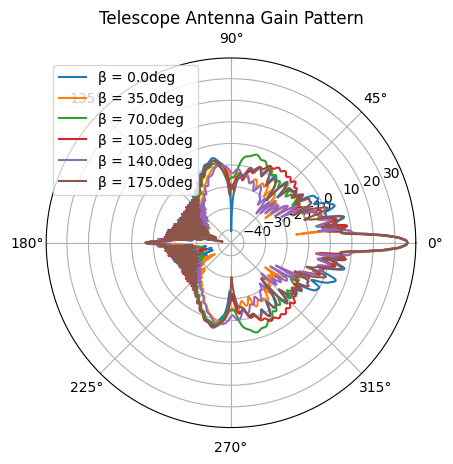

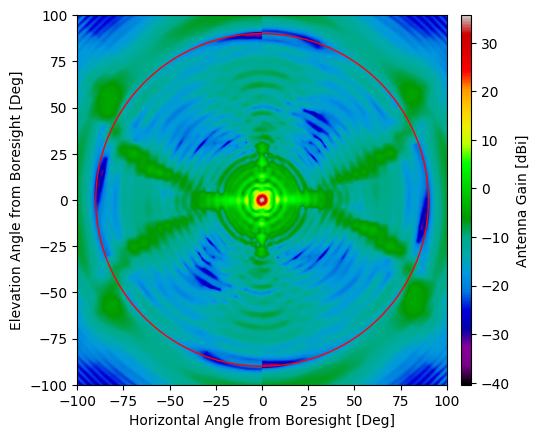

In [13]:
# ## Define the instrument used to observe
# ---

# ### The antenna
#
# The first step to define the instrument of observation is to define the antenna
# used. The package has a custom structure `Antenna` that takes as inputs a
# `DataFrame` structure with columns `alphas`, `betas` and `gains`, containing
# the gain values and their angle coordinates (α,β), the estimated
# radiation efficiency and the frequency band where the model of antenna defined
# is valid. α∈[0,180] and β∈[0,360[ are defined such that when
# the antenna is pointing at the horizon, β=0 gives a vertical slice of the
# pattern, with α>0 oriented towards the ground.
#
# A path to a `.cut` file defining the power pattern model can be given in place
# of the `DataFrame` structure to load and format the gain pattern. In that case,
# it is possible to give the tags of the different columns if other names are
# present in the table to load.

# radiation efficiency of telescope antenna
eta_rad = 0.98 - 0.015 #0.015 is for radome loss

# valid frequency band of gain pattern model
freq_band = (1.40e9, 1.427e9)  # in Hz

# Get the directory where this script is located
script_dir = os.path.dirname(os.path.abspath('__file__'))

# load telescope antenna
file_pattern_path = os.path.join(script_dir, "data", "MRT_beam_pattern_1420MHz_RHCP.cut")
tel_ant = Antenna.from_file(
    file_pattern_path,
    eta_rad,
    freq_band,
    power_tag='power',
    declination_tag='alpha',
    azimuth_tag='beta'
)

# The result is an `Antenna` storing the different information and an interpolated
# version of the gain pattern.

# plot gain pattern
nb_curv = 5  # number of slices to plot
alphas, betas = tel_ant.get_def_angles()
step_beta_ind = len(betas) // (2 * nb_curv)
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
for i in range(0, len(betas) // 2, step_beta_ind):
    a, g = tel_ant.get_slice_gain(betas[i])
    ax.plot(np.radians(a), 10 * np.log10(g), label=f"β = {betas[i]}deg")
ax.legend()
plt.title("Telescope Antenna Gain Pattern")
plt.show()

# plot gain pattern projected in cartesian coords

angle_range = [-100, 100]
extent = [angle_range[0],angle_range[1],angle_range[0],angle_range[1]]

xangles = np.linspace(angle_range[0], angle_range[1], 1500)
yangles = np.linspace(angle_range[0], angle_range[1], 1500)

x, y = np.meshgrid(xangles, yangles)

points = np.array([x,y]).swapaxes(0,1)
alphas = np.sqrt(np.sum(np.power(points,2),axis=1))/180 * np.pi
betas = (np.arctan2(y, x) - np.pi/2 )%np.pi #subtraction of pi/2 rotates definition for correct horizon orientation in plot

gain_pattern = tel_ant.get_gain_values(alphas,betas)

circle = plt.Circle((0, 0), 90, color='r', fill=False,)

fig = plt.figure()
ax = plt.gca()

im = ax.imshow(
    10*np.log10(gain_pattern),
    origin='lower',
    extent=extent,
    cmap='nipy_spectral')

ax.add_patch(circle)

ax.set_xlabel('Horizontal Angle from Boresight [Deg]')
ax.set_ylabel('Elevation Angle from Boresight [Deg]')

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, aspect=0.5)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Antenna Gain [dBi]')

plt.show()

## Instrument Setup and Environmental Configuration

- Instrument configuration with telescope parameters
- Environmental effects setup with DEM and atmospheric conditions
- Observation plan with trajectory loading and filtering
- Sky model with all temperature components and visualization

In [14]:
# ### The instrument
#
# To define the `Instrument` of observation as a structure, we need an `Antenna`
# structure, as well as other parameters:
# - the physical temperature of the antenna;
# - the frequency of observation;
# - the bandwidth of the instrument;
# - the receiver temperature as a function of time (`datetime` type) and frequency;
# It is also possible to specify:
# - the number of frequency channels to divide the bandwidth of the instrument by
#   (default is 1);
# - the coordinates of the instrument as a vector (not used as of now);

# telescope antenna physical temperature
T_phy = 300.0  # in K

# frequency of observation
cent_freq = 1.4135e9  # in Hz

# bandwidth of telescope receiver
bw = 27e6  # in Hz

# number of frequency channels to divide the bandwidth
freq_chan = 1

# telescope receiver temperature (constant over the bandwidth)
def T_RX(tim, freq):
    return 16  # in K

# coordinates of telescope
coords = [42.360236, -71.089478, 97.0]

# create instrument
MRT = Instrument(tel_ant, T_phy, cent_freq, bw, T_RX, freq_chan, coords)

In [27]:
# environmental: Initialize environmental effects
lat = coords[0]  # degrees
lon = coords[1]  # degrees
elevation = coords[2]  # meters above sea level

# Atmospheric conditions (January in Cambridge, MA)
temperature = 272.0  # K (-1°C)
pressure = 101767  # Pa (1 atm)
humidity = 63.0  # % (moderate humidity)

# Environmental effects configuration
environmental_config = {
    'dem_file': os.path.join(script_dir, "data", "USGS_OPR_MA_CentralEastern_2021_B21_be_19TBH294720.tif"),
    'antenna_lat': lat,
    'antenna_lon': lon,
    'antenna_elevation': elevation,
    'temperature': temperature,
    'pressure': pressure,
    'humidity': humidity,
    'min_elevation_angle': 5.0,  # degrees
    'apply_terrain_masking': True,
    'apply_atmospheric_effects': True,
    'apply_limb_refraction': True
}

# Initialize environmental effects
print("Initializing environmental effects...")
environment = AdvancedEnvironmentalEffects(
    environmental_config['dem_file'], lat, lon, elevation,
    temperature, pressure, humidity
)

Initializing environmental effects...
DEM loaded successfully:
  Shape: (3000, 3000)
  CRS: COMPD_CS["NAD83(2011) / UTM zone 19N + NAVD88 height - Geoid18 (m)",PROJCS["NAD83(2011) / UTM zone 19N",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6348"]],VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG"

## Sky Model without Sources and without antenna convolution


NOTE: we DO NOT use a simplified atmospheric model here. we use a full downwelling calculation

In [29]:
# ### Sky model
#
# Accounting for the sky components is important to have a realistic simulation of
# the power received.
#
# Given the fact that we will point at Cas A for a part of the observation, we
# need to account for the difference of temperature depending on the pointing position:

# source flux
flux_src = 0  # in Jy

# Pre-calculate effective aperture for performance optimization
max_gain = tel_ant.get_boresight_gain()
A_eff_max = antenna_pattern.gain_to_effective_aperture(max_gain, cent_freq)

# source temperature in K
def T_src(t):
    if t <= time_on_src:
        return 0.0
    else:
        # use A_eff_max instead of observ
        return estim_temp(flux_src, A_eff_max)

# Same for the RFI and the background sources that can be modeled as constants as a first approximation:

# ground temperature in K
T_gnd = 120  # Ground temp allowing for a nonzero emissivity (whould really model this properly)

# various RFI
T_var = 0  # in K (no RFI)

# total RFI temperature
T_rfi = T_gnd + T_var

# CMB temperature
T_CMB = 2.73  # in K

# galaxy temperature
def T_gal(freq): return 1e-1 * (freq/1.41e9)**(-2.7)  # in K

# background
def T_bkg(freq): return T_CMB + T_gal(freq)

azimuth_grid = np.arange(0, 361, 5)
elevation_grid = np.arange(0, 91, 1)
az_grid, el_grid = np.meshgrid(azimuth_grid, elevation_grid)

elevation_calcs = []


for e in elevation_grid:
    res = environment.calculate_integrated_atmospheric_effects(e, MRT.get_center_freq())

    print(f"{e} degrees: water att = {res[2]} dB, total att = {res[4]} dB, temp = {res[3]} K") 



1413500000.0
0 degrees: water att = 0.0 dB, total att = 0.0 dB, temp = 0.0 K
1 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
2 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
3 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
4 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
5 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
6 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
7 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
8 degrees: water att = 0.01184878762399641 dB, total att = 0.011906254243972793 dB, temp = 0.7017292004534159 K
9 degrees: water att = 0.01

In [ ]:
# plot of sky model without source

sky_temp = np.vectorize(
    lambda el, az: sky_mdl(np.radians(90-el), -np.radians(az), start_obs, cent_freq)
)(el_grid, az_grid)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, polar=True)
pc = ax.pcolormesh(np.radians(azimuth_grid), 90-elevation_grid, sky_temp, cmap="plasma")
cbar = plt.colorbar(pc)
cbar.set_label("Temperature [K]")
ax.set_yticks(range(0, 91, 10))
ax.set_yticklabels([str(x) for x in range(90, -1, -10)])
ax.set_theta_zero_location("N")
plt.title("Sky Model Temperature Map")
plt.show()